<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/tens_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [8]:
from sklearn.datasets import make_moons


x, y = make_moons(n_samples=1000, random_state=42, noise=0.03)

In [9]:
x[:5]

array([[-0.00933187,  0.39098105],
       [ 0.95457387, -0.47375583],
       [ 0.9185256 , -0.42519648],
       [ 0.41276802, -0.37638459],
       [-0.84532016,  0.52879908]])

In [10]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

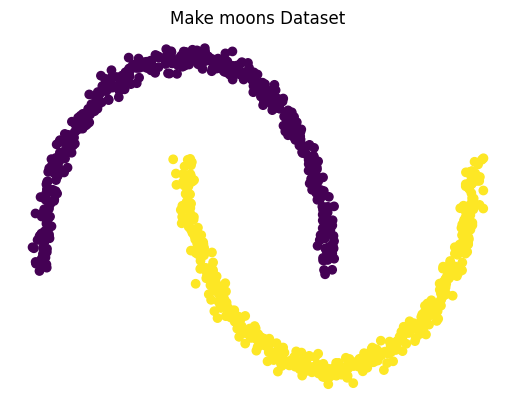

In [11]:
import matplotlib.pyplot as plt


plt.scatter(x[:,0], x[:,1], c=y)
plt.title("Make moons Dataset")
plt.axis("off")
plt.show()

In [14]:
x.shape

(1000, 2)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
len(X_train), len(X_test)

(800, 200)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [25]:
model = Sequential()
model.add(Dense(units=8, activation="relu", input_shape=(2,)))
model.add(Dense(units=8, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer="sgd", loss="binary_crossentropy", metrics=['accuracy'])

In [28]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4313 - loss: 0.7108 - val_accuracy: 0.4750 - val_loss: 0.6974
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5325 - loss: 0.6807 - val_accuracy: 0.5750 - val_loss: 0.6674
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6712 - loss: 0.6539 - val_accuracy: 0.7250 - val_loss: 0.6402
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7613 - loss: 0.6294 - val_accuracy: 0.8050 - val_loss: 0.6159
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7975 - loss: 0.6067 - val_accuracy: 0.8250 - val_loss: 0.5932
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8325 - loss: 0.5849 - val_accuracy: 0.8350 - val_loss: 0.5712
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8612 - loss: 0.5636 - val_accuracy: 0.8450 - val_loss: 0.5494
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.5428 - val_accuracy: 0.8750 - val_loss

In [30]:
Epochs = history.epoch
Epochs

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [32]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [33]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

In [37]:
print(accuracy[:5])
print(loss[:5])
print(val_accuracy[:5])
print(val_loss[:5])

[0.4312500059604645, 0.5325000286102295, 0.6712499856948853, 0.7612500190734863, 0.7975000143051147]
[0.7107546925544739, 0.6806776523590088, 0.6538642644882202, 0.6294312477111816, 0.6066507697105408]
[0.4749999940395355, 0.574999988079071, 0.7250000238418579, 0.8050000071525574, 0.824999988079071]
[0.6973512172698975, 0.6673521399497986, 0.6402438879013062, 0.6158962845802307, 0.5932469367980957]


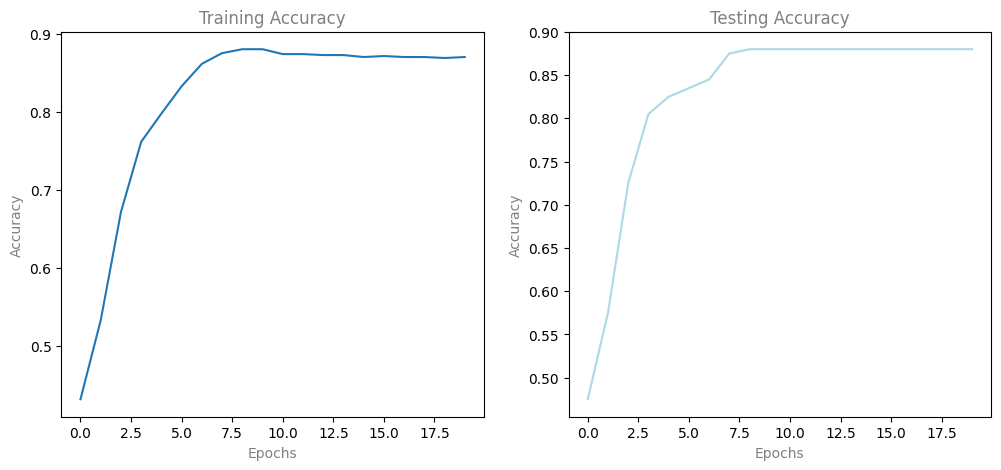

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(Epochs, accuracy)
ax[0].set_title("Training Accuracy", c="gray")
ax[0].set_xlabel("Epochs", c="gray")
ax[0].set_ylabel("Accuracy", c="gray")
ax[1].plot(Epochs, val_accuracy, c="lightblue")
ax[1].set_title("Testing Accuracy", c="gray")
ax[1].set_xlabel("Epochs", c="gray")
ax[1].set_ylabel("Accuracy", c="gray")
plt.show()

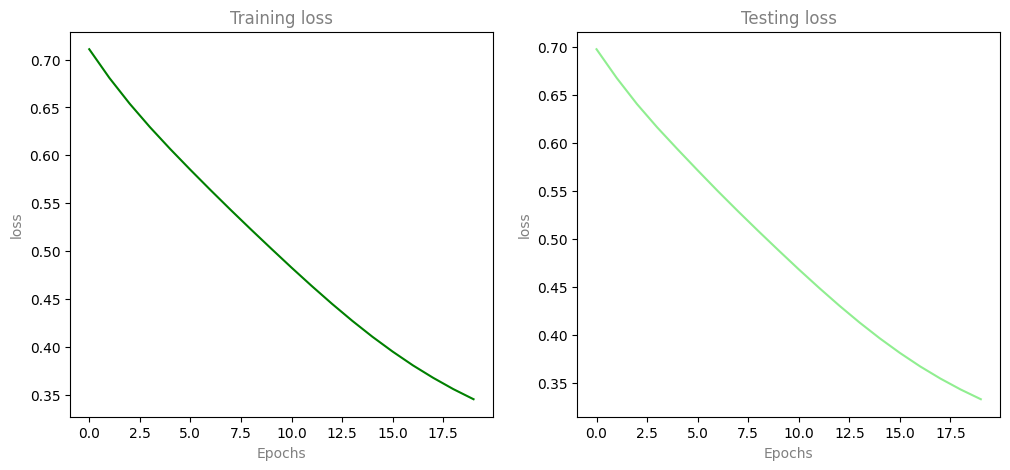

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(Epochs, loss, c="green")
ax[0].set_title("Training loss", c="gray")
ax[0].set_xlabel("Epochs", c="gray")
ax[0].set_ylabel("loss", c="gray")
ax[1].plot(Epochs, val_loss, c="lightgreen")
ax[1].set_title("Testing loss", c="gray")
ax[1].set_xlabel("Epochs", c="gray")
ax[1].set_ylabel("loss", c="gray")
plt.show()

In [51]:
test = X_test[0]
test, y_test[0]

(array([-0.6536981,  0.773369 ]), np.int64(0))

In [55]:
test.shape

(2,)

In [53]:
import numpy as np

test_expanded = np.expand_dims(test, axis=0)
test_expanded

array([[-0.6536981,  0.773369 ]])

In [54]:
test_expanded.shape

(1, 2)

In [56]:
model.predict(test_expanded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


array([[0.16098392]], dtype=float32)

In [59]:
test2 = X_test[1]
print(test2, test2.shape)
print(y_test[1])
test2_exp = np.expand_dims(test2, axis=0)
print(test2_exp, test2_exp.shape)

[ 1.16188881 -0.56673475] (2,)
1
[[ 1.16188881 -0.56673475]] (1, 2)


In [60]:
model.predict(test2_exp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


array([[0.8720494]], dtype=float32)